# Customer Churn Prediction

# Milestone 5: Model Training

## Objective

The objective of this milestone is to train multiple machine learning models using the preprocessed dataset and compare their performance.

The models will be evaluated using several classification metrics to determine the most suitable model for customer churn prediction.

In [9]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [10]:
import pandas as pd

from src.preprocessing import (
    clean_data,
    handle_missing_values,
    encode_target,
    split_data,
    create_preprocessor,
    apply_smote
)

In [11]:
# Load dataset

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Cleaning

df = clean_data(df)

df = handle_missing_values(df)

df = encode_target(df)

# Split

X_train, X_test, y_train, y_test = split_data(df)

# Preprocess

preprocessor = create_preprocessor()

X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

# SMOTE

X_train, y_train = apply_smote(
    X_train,
    y_train
)

In [12]:
from src.train import (
    get_models,
    train_models
)

models = get_models()

trained_models = train_models(
    models,
    X_train,
    y_train
)

In [13]:
trained_models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Hist Gradient Boosting'])

In [14]:
from src.evaluate import compare_models

results = compare_models(
    trained_models,
    X_test,
    y_test
)

results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7321,0.4974,0.7781,0.6069,0.7467
3,Gradient Boosting,0.7719,0.5572,0.6898,0.6165,0.7457
4,Hist Gradient Boosting,0.7804,0.5823,0.6150,0.5982,0.7276
2,Random Forest,0.7775,0.5818,0.5802,0.5810,0.7146
1,Decision Tree,0.7129,0.4656,0.5428,0.5012,0.6586


In [15]:
from src.evaluate import (
    plot_confusion_matrix,
    plot_roc_curve
)

<Figure size 600x500 with 0 Axes>

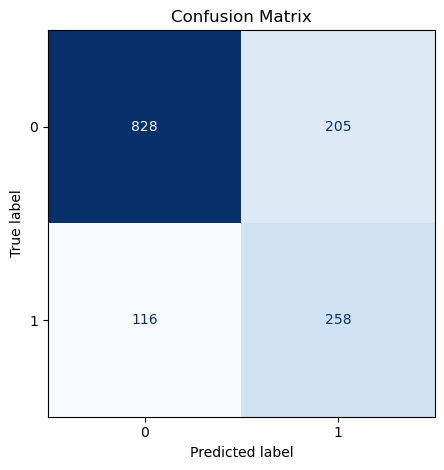

In [16]:
best_model = trained_models["Gradient Boosting"]

plot_confusion_matrix(
    best_model,
    X_test,
    y_test
)


<Figure size 600x500 with 0 Axes>

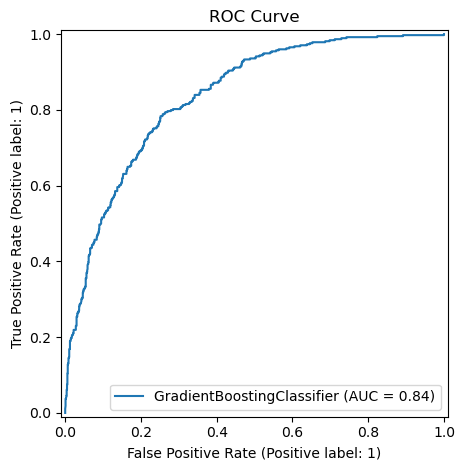

In [17]:
plot_roc_curve(
    best_model,
    X_test,
    y_test
)

In [18]:
from src.pipeline import create_pipeline

pipeline = create_pipeline(
    preprocessor,
    trained_models["Gradient Boosting"]
)

In [19]:
import joblib

best_model = trained_models["Gradient Boosting"]

joblib.dump(
    best_model,
    "../models/gradient_boosting_model.pkl"
)

print("Model saved successfully!")

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Model saved successfully!
Preprocessor saved successfully!


In [20]:
loaded_model = joblib.load("../models/gradient_boosting_model.pkl")

loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print(type(loaded_model))
print(type(loaded_preprocessor))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [21]:
df.to_csv("../data/processed/cleaned_telco.csv", index=False)